In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
## 1. Load and Clean Dataset

df = pd.read_csv("/content/online_shoppers_intention.csv")

df = df.drop_duplicates().reset_index(drop=True)

df.shape

(12205, 18)

In [5]:
## 2. Separate Features and Target

# Features: all columns except the target
X = df.drop(columns="Revenue")

# Target: whether the session resulted in a purchase
y = df["Revenue"].astype(int)

In [6]:
X.shape, y.shape

((12205, 17), (12205,))

In [7]:
X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True


In [8]:
y.value_counts()

,count
Revenue,
0,10297
1,1908


In [9]:
## 3. Encode Categorical Features

categorical_cols = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

X_encoded.shape

(12205, 68)

In [10]:
X_encoded.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_True
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,False,False,False,False,False,False,False,False,True,True


In [11]:
## 4. Train-Test Split

from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [12]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (9764, 68)
X_test: (2441, 68)
y_train: (9764,)
y_test: (2441,)


In [13]:
print("Training conversion rate:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest conversion rate:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training conversion rate:
Revenue
0    84.37
1    15.63
Name: proportion, dtype: float64

Test conversion rate:
Revenue
0    84.35
1    15.65
Name: proportion, dtype: float64


In [14]:
## 5. Scale Numerical Features

from sklearn.preprocessing import StandardScaler

numeric_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()

X_train_scaled[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test_scaled[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

In [15]:
X_train_scaled[numeric_cols].head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
7469,1.689206,0.676238,0.381750,-0.243015,0.220868,-0.080395,-0.448703,-0.800192,1.665596,-0.311837
11804,-0.699498,-0.458067,-0.397879,-0.243015,-0.046900,-0.158842,-0.448703,-0.739774,1.495448,-0.311837
3250,-0.699498,-0.458067,-0.397879,-0.243015,-0.426237,-0.408089,-0.448703,-0.287446,-0.315264,3.689185
204,-0.102322,-0.235218,-0.397879,-0.243015,-0.604748,-0.336795,-0.448703,-0.279507,-0.315264,-0.311837
4392,-0.699498,-0.458067,-0.397879,-0.243015,-0.359295,0.203501,-0.448703,-0.609743,-0.315264,-0.311837


In [16]:
## 6. Baseline Model

from sklearn.dummy import DummyClassifier

# Baseline model: always predicts the most common class
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(
    X_train_scaled,
    y_train
)

baseline_predictions = baseline_model.predict(
    X_test_scaled
)

In [17]:
from sklearn.metrics import accuracy_score

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print("Baseline Accuracy:", round(baseline_accuracy, 4))

Baseline Accuracy: 0.8435


In [18]:
## 7. Logistic Regression Model
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000)

In [19]:

logistic_predictions = logistic_model.predict(
    X_test_scaled
)

logistic_probabilities = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

In [20]:
logistic_predictions[:10]

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [21]:
logistic_probabilities[:10]

array([0.14305957, 0.17703169, 0.10537818, 0.05436054, 0.0018069 ,
       0.60537131, 0.00929746, 0.07573101, 0.12224914, 0.02020178])

In [22]:
## 8. Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, logistic_predictions)
precision = precision_score(y_test, logistic_predictions)
recall = recall_score(y_test, logistic_predictions)
f1 = f1_score(y_test, logistic_predictions)
roc_auc = roc_auc_score(y_test, logistic_probabilities)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

Accuracy: 0.8878
Precision: 0.7571
Recall: 0.4162
F1-score: 0.5372
ROC-AUC: 0.8997


In [23]:
print(classification_report(y_test, logistic_predictions))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      2059
           1       0.76      0.42      0.54       382

    accuracy                           0.89      2441
   macro avg       0.83      0.70      0.74      2441
weighted avg       0.88      0.89      0.87      2441



In [24]:
cm = confusion_matrix(y_test, logistic_predictions)

print(cm)

[[2008   51]
 [ 223  159]]


In [25]:
## 9. Class-Weighted Logistic Regression

# Because purchase sessions represent only about 16% of the dataset, the standard model may favor the majority non-purchase class.

# A second Logistic Regression model is trained using `class_weight="balanced"`, which gives greater importance to mistakes made on the minority purchase class without generating synthetic data.

In [26]:
# Train Logistic Regression with balanced class weights
balanced_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

balanced_model.fit(
    X_train_scaled,
    y_train
)

balanced_predictions = balanced_model.predict(
    X_test_scaled
)

balanced_probabilities = balanced_model.predict_proba(
    X_test_scaled
)[:, 1]

In [27]:
balanced_accuracy = accuracy_score(
    y_test,
    balanced_predictions
)

balanced_precision = precision_score(
    y_test,
    balanced_predictions
)

balanced_recall = recall_score(
    y_test,
    balanced_predictions
)

balanced_f1 = f1_score(
    y_test,
    balanced_predictions
)

balanced_auc = roc_auc_score(
    y_test,
    balanced_probabilities
)

print("Accuracy:", round(balanced_accuracy, 4))
print("Precision:", round(balanced_precision, 4))
print("Recall:", round(balanced_recall, 4))
print("F1-score:", round(balanced_f1, 4))
print("ROC-AUC:", round(balanced_auc, 4))

Accuracy: 0.848
Precision: 0.5092
Recall: 0.7958
F1-score: 0.621
ROC-AUC: 0.9096


In [28]:
## Model Comparison: Class weighting substantially improved the model's ability to identify purchasers. Recall increased from **41.62% to 79.58%**, while F1-score improved from **53.72% to 62.10%** and ROC-AUC increased slightly to **0.91**.

## The trade-off was lower precision, which fell from **75.71% to 50.92%**. This means the balanced model identifies many more potential purchasers, but also produces more false positives.

In [29]:
balanced_cm = confusion_matrix(
    y_test,
    balanced_predictions
)

print(balanced_cm)

[[1766  293]
 [  78  304]]


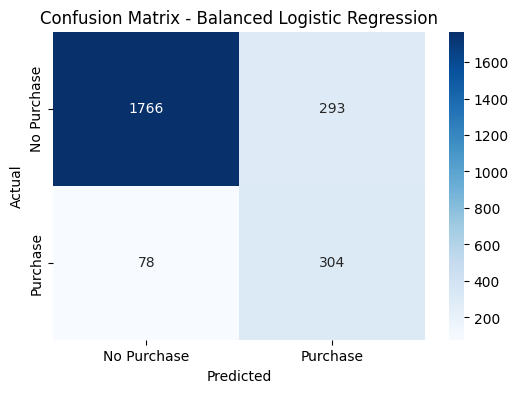

In [30]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    balanced_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [32]:
## 10. Compare Standard and Balanced Logistic Regression

model_comparison = pd.DataFrame({
    "Model": ["Standard Logistic Regression", "Balanced Logistic Regression"],
    "Accuracy": [accuracy, balanced_accuracy],
    "Precision": [precision, balanced_precision],
    "Recall": [recall, balanced_recall],
    "F1-Score": [f1, balanced_f1],
    "ROC-AUC": [roc_auc, balanced_auc]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Standard Logistic Regression,0.8878,0.7571,0.4162,0.5372,0.8997
1,Balanced Logistic Regression,0.8480,0.5092,0.7958,0.6210,0.9096


In [33]:
## 11. PageValues Sensitivity Analysis

# 'PageValues' showed a much stronger relationship with conversion than the other numerical features. To understand how dependent the model is on this variable, we train the balanced Logistic Regression model again after removing `PageValues`.

In [34]:
# Create training and test sets without PageValues
X_train_no_pagevalue = X_train_scaled.drop(columns="PageValues")
X_test_no_pagevalue = X_test_scaled.drop(columns="PageValues")

In [35]:
# Train balanced Logistic Regression without PageValues
model_no_pagevalue = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model_no_pagevalue.fit(
    X_train_no_pagevalue,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [36]:
pred_no_pagevalue = model_no_pagevalue.predict(
    X_test_no_pagevalue
)

prob_no_pagevalue = model_no_pagevalue.predict_proba(
    X_test_no_pagevalue
)[:, 1]

In [37]:
accuracy_no_pv = accuracy_score(y_test, pred_no_pagevalue)
precision_no_pv = precision_score(y_test, pred_no_pagevalue)
recall_no_pv = recall_score(y_test, pred_no_pagevalue)
f1_no_pv = f1_score(y_test, pred_no_pagevalue)
auc_no_pv = roc_auc_score(y_test, prob_no_pagevalue)

print("Accuracy:", round(accuracy_no_pv, 4))
print("Precision:", round(precision_no_pv, 4))
print("Recall:", round(recall_no_pv, 4))
print("F1-score:", round(f1_no_pv, 4))
print("ROC-AUC:", round(auc_no_pv, 4))

Accuracy: 0.6489
Precision: 0.2782
Recall: 0.7801
F1-score: 0.4102
ROC-AUC: 0.7556


In [38]:
## 12. Classification Threshold Analysis

# Logistic Regression produces a purchase probability for each session. By default, probabilities above 0.50 are classified as purchases.

# Different business scenarios may require different trade-offs between precision and recall, so we evaluate several probability thresholds.

In [39]:
thresholds = [0.50, 0.40, 0.30, 0.20]

threshold_results = []

for threshold in thresholds:

    predictions = (
        logistic_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.round(4)

,Threshold,Precision,Recall,F1-Score
0,0.5,0.7571,0.4162,0.5372
1,0.4,0.7287,0.4712,0.5723
2,0.3,0.6788,0.5864,0.6292
3,0.2,0.5398,0.7277,0.6198


In [40]:
## Insight: Lowering the classification threshold improved the balance between precision and recall. A threshold of **0.30** achieved the highest F1-score (**62.92%**), with **67.88% precision** and **58.64% recall**. This provides a more balanced alternative to the default 0.50 threshold, which was highly precise but missed many actual purchasers.

In [41]:
# Generate predictions using the selected 0.30 threshold
selected_threshold = 0.30

final_predictions = (
    logistic_probabilities >= selected_threshold
).astype(int)

In [42]:
final_cm = confusion_matrix(
    y_test,
    final_predictions
)

print(final_cm)

[[1953  106]
 [ 158  224]]


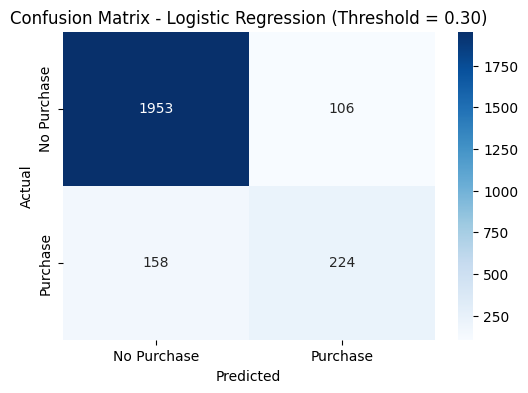

In [43]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Confusion Matrix - Logistic Regression (Threshold = 0.30)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [44]:
## Interpretation:** At the selected 0.30 threshold, the model correctly identified **224 of 382 actual purchasers**, while missing **158**. Lowering the threshold increased the number of purchasers detected compared with the default 0.50 threshold, at the cost of additional false-positive predictions.

In [45]:
## 13. Feature Importance and Model Interpretation

# Extract Logistic Regression coefficients
coefficients = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficients = coefficients.sort_values(
    "Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient
8,PageValues,1.523464
52,TrafficType_8,0.640152
36,Browser_12,0.616218
54,TrafficType_10,0.581629
16,Month_Nov,0.544976
51,TrafficType_7,0.516288
37,Browser_13,0.346342
64,TrafficType_20,0.332186
55,TrafficType_11,0.299643
24,OperatingSystems_7,0.270319


In [46]:
coefficients.tail(10)

,Feature,Coefficient
30,Browser_6,-0.393781
15,Month_May,-0.409413
31,Browser_7,-0.453294
57,TrafficType_13,-0.484517
14,Month_Mar,-0.497970
59,TrafficType_15,-0.501533
10,Month_Dec,-0.635262
7,ExitRates,-0.784825
27,Browser_3,-0.887730
11,Month_Feb,-1.189399


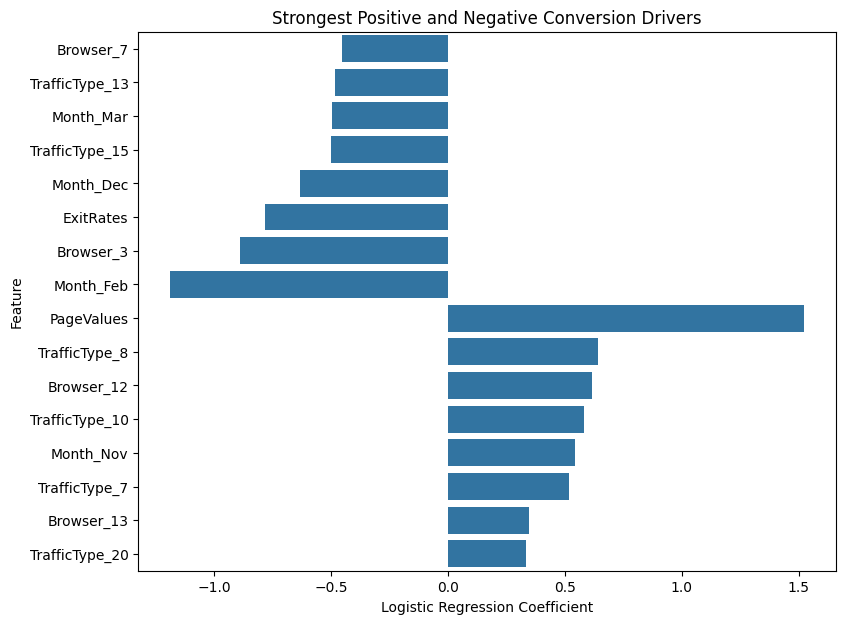

In [47]:
# Select strongest positive and negative coefficients
top_positive = coefficients.head(8)
top_negative = coefficients.tail(8)

top_coefficients = pd.concat([
    top_negative,
    top_positive
])

plt.figure(figsize=(9, 7))

sns.barplot(
    data=top_coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Strongest Positive and Negative Conversion Drivers")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

In [48]:
## 14. Odds Ratio Interpretation

# Calculate odds ratios for key behavioral features
key_features = ["PageValues", "ExitRates"]

odds_ratios = coefficients[
    coefficients["Feature"].isin(key_features)
].copy()

odds_ratios["Odds_Ratio"] = np.exp(
    odds_ratios["Coefficient"]
)

odds_ratios.round(3)

,Feature,Coefficient,Odds_Ratio
8,PageValues,1.523,4.588
7,ExitRates,-0.785,0.456


In [49]:
## Interpretation: A one-standard-deviation increase in 'PageValues' was associated with approximately 4.6× higher odds of purchase, holding the other model variables constant. In contrast, a one-standard-deviation increase in 'ExitRates' was associated with approximately 54% lower purchase odds.

In [51]:
## 15. Final Model Decision

#The standard Logistic Regression model provided strong precision but relatively low recall at the default 0.50 threshold.

## Using a lower threshold of 0.30 improved the balance between precision and recall, achieving:

# Precision: 67.88%
# Recall: 58.64%
# F1-score: 62.92%

# The balanced Logistic Regression model achieved much higher recall (79.58%) but lower precision (50.92%).

# Therefore, the preferred model configuration depends on the business cost of false positives versus missed purchasers.

## 16. Business Recommendations

The analysis suggests several ways an e-commerce product or marketing team could use these insights.

### High-Intent Session Targeting

For low-cost interventions such as personalized recommendations, reminders, or checkout prompts, a lower probability threshold such as **0.30** could be used to identify a broader set of potential purchasers.

This increases recall while maintaining reasonable precision.

### High-Engagement Non-Converters

Converting sessions viewed substantially more product pages and spent more time on product-related content.

Users who show similarly high product engagement but still do not purchase could be investigated for possible checkout friction, pricing concerns, trust issues, or product availability.

Additional funnel tracking or A/B testing would be required to identify the actual cause.

### Exit Rate Reduction

Higher 'ExitRates' were strongly associated with lower conversion likelihood.

Product teams could examine pages with high exit behavior, especially near important stages of the purchase journey, and test improvements to navigation, product information, or checkout flow.

### Seasonal Campaign Planning

November showed the highest observed conversion rate at **25.49%**, suggesting stronger purchase intent during that period.

Marketing and merchandising teams could consider increasing campaign intensity or promotional visibility during high-conversion periods, while validating whether the pattern remains consistent across additional years of data.


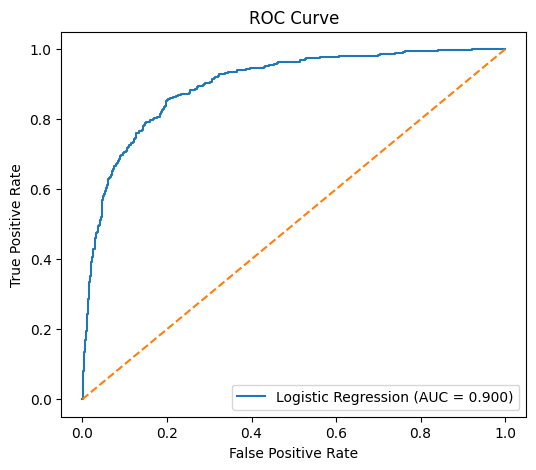

In [52]:
## 17. ROC Curve
from sklearn.metrics import roc_curve

# Calculate ROC curve for the standard Logistic Regression model
fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    logistic_probabilities
)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## 18. Project Summary

- Analyzed **12,205 unique online shopping sessions** after removing 125 exact duplicate records.
- Purchase conversion rate was only **15.63%**, creating a clear class imbalance.
- Converting sessions viewed a median of **29 product pages vs 16** for non-converting sessions and spent about **2.1× more time** on product-related pages.
- Non-converting sessions had approximately **4.5× higher bounce rates** and **2.3× higher exit rates**.
- Standard Logistic Regression achieved **0.90 ROC-AUC**, but recall was only **41.62%** at the default threshold.
- Class weighting increased recall to **79.58%**, although precision fell to **50.92%**.
- A **0.30 probability threshold** provided a more balanced result with **67.88% precision, 58.64% recall, and 62.92% F1-score**.
- 'PageValues' was the strongest predictor; removing it reduced ROC-AUC from approximately **0.91 to 0.76**, showing substantial dependence on this feature.
- Model coefficients and business analysis highlighted 'PageValues', exit behavior, product engagement, and seasonality as important signals associated with purchase conversion.